In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import Counter
import os
from sklearn.metrics import confusion_matrix, classification_report


2026-01-26 23:24:47.375718: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769469887.581850      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769469887.639964      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769469888.140950      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769469888.140991      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769469888.140994      55 computation_placer.cc:177] computation placer alr

In [2]:

BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
SEED = 42
EPOCHS = 20
LEARNING_RATE = 1e-3
TRAIN_SPLIT = 0.8  
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
DATA_DIR = '/kaggle/input/chest-xray-pneumonia/chest_xray'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')
TEST_DIR = os.path.join(DATA_DIR, 'test')
class_names = sorted(os.listdir(TRAIN_DIR))
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
num_classes = len(class_names)

print(f"\nClasses found: {class_names}")
print(f"Number of classes: {num_classes}")
def count_images_per_class(directory):
    """Count images per class in a directory"""
    counts = {}
    total = 0
    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)
        if os.path.exists(class_dir):
            count = len([f for f in os.listdir(class_dir) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            counts[class_name] = count
            total += count
    return counts, total

original_train_counts, original_train_total = count_images_per_class(TRAIN_DIR)
original_val_counts, original_val_total = count_images_per_class(VAL_DIR)
test_counts, test_total = count_images_per_class(TEST_DIR)

print(f"\nOriginal Dataset Distribution:")
print(f"  Train: {original_train_total} images")
for class_name in class_names:
    print(f"    - {class_name}: {original_train_counts[class_name]}")

print(f"  Validation: {original_val_total} images (TOO SMALL!)")
for class_name in class_names:
    print(f"    - {class_name}: {original_val_counts[class_name]}")

print(f"  Test: {test_total} images")
for class_name in class_names:
    print(f"    - {class_name}: {test_counts[class_name]}")



Classes found: ['NORMAL', 'PNEUMONIA']
Number of classes: 2

Original Dataset Distribution:
  Train: 5216 images
    - NORMAL: 1341
    - PNEUMONIA: 3875
  Validation: 16 images (TOO SMALL!)
    - NORMAL: 8
    - PNEUMONIA: 8
  Test: 624 images
    - NORMAL: 234
    - PNEUMONIA: 390


In [4]:
train_images = []
train_labels = []

for class_name in class_names:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue
    
    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(class_dir, img_name)
            train_images.append(img_path)
            train_labels.append(class_to_idx[class_name])

train_images = np.array(train_images)
train_labels = np.array(train_labels)

print(f"\nOriginal Training Set: {len(train_images)} images")

# Split into new train and validation with stratification
new_train_paths, new_val_paths, new_train_labels, new_val_labels = train_test_split(
    train_images,
    train_labels,
    test_size=(1 - TRAIN_SPLIT),  # 20% for validation
    stratify=train_labels,
    random_state=SEED
)

print(f"\nNew Split (from original training set):")
print(f"  New Train: {len(new_train_paths)} images ({len(new_train_paths)/len(train_images)*100:.1f}%)")
for idx, class_name in enumerate(class_names):
    print(f"    - {class_name}: {np.sum(new_train_labels == idx)}")

print(f"  New Validation: {len(new_val_paths)} images ({len(new_val_paths)/len(train_images)*100:.1f}%)")
for idx, class_name in enumerate(class_names):
    print(f"    - {class_name}: {np.sum(new_val_labels == idx)}")


test_images = []
test_labels = []

for class_name in class_names:
    class_dir = os.path.join(TEST_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue
    
    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(class_dir, img_name)
            test_images.append(img_path)
            test_labels.append(class_to_idx[class_name])

test_images = np.array(test_images)
test_labels = np.array(test_labels)

print(f"\n  Test: {len(test_images)} images")
for idx, class_name in enumerate(class_names):
    print(f"    - {class_name}: {np.sum(test_labels == idx)}")


Original Training Set: 5216 images

New Split (from original training set):
  New Train: 4172 images (80.0%)
    - NORMAL: 1073
    - PNEUMONIA: 3099
  New Validation: 1044 images (20.0%)
    - NORMAL: 268
    - PNEUMONIA: 776

  Test: 624 images
    - NORMAL: 234
    - PNEUMONIA: 390


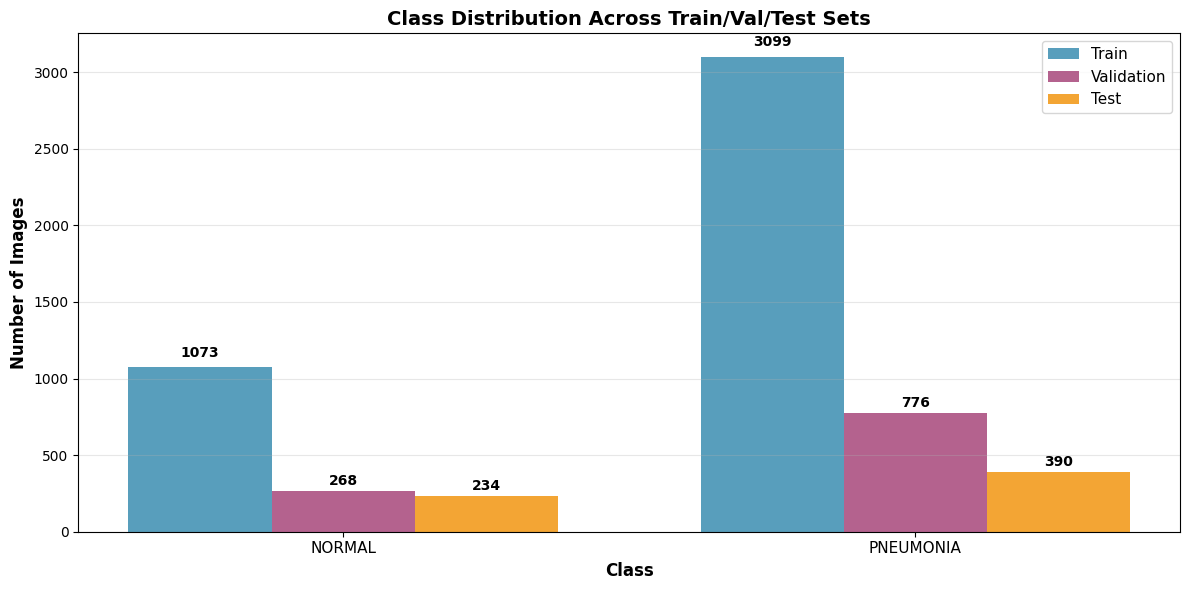

In [5]:
def plot_class_distribution(train_labels, val_labels, test_labels, class_names):
    """Plot class distribution across splits"""
    
    train_counts = Counter(train_labels)
    val_counts = Counter(val_labels)
    test_counts = Counter(test_labels)
    
    x = np.arange(len(class_names))
    width = 0.25
    
    train_vals = [train_counts[i] for i in range(len(class_names))]
    val_vals = [val_counts[i] for i in range(len(class_names))]
    test_vals = [test_counts[i] for i in range(len(class_names))]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.bar(x - width, train_vals, width, label='Train', alpha=0.8, color='#2E86AB')
    ax.bar(x, val_vals, width, label='Validation', alpha=0.8, color='#A23B72')
    ax.bar(x + width, test_vals, width, label='Test', alpha=0.8, color='#F18F01')
    
    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
    ax.set_title('Class Distribution Across Train/Val/Test Sets', 
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (t, v, te) in enumerate(zip(train_vals, val_vals, test_vals)):
        ax.text(i - width, t + 50, str(t), ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.text(i, v + 20, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
        ax.text(i + width, te + 20, str(te), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    

plot_class_distribution(new_train_labels, new_val_labels, test_labels, class_names)


In [6]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")


I0000 00:00:1769469902.117625      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [7]:
def create_dataset(image_paths, labels, preprocess_fn, augment=False, shuffle=True):
    """Create TF dataset from paths and labels"""
    
    def load_and_preprocess(path, label):
        # Read image
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        return img, label
    
    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=SEED)
    
    dataset = dataset.batch(BATCH_SIZE)
    
    if augment:
        dataset = dataset.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    
    dataset = dataset.map(
        lambda x, y: (preprocess_fn(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    
    return dataset.prefetch(tf.data.AUTOTUNE)


In [8]:
def preprocess_densenet(x):
    return preprocess_input(x)
train_ds_dense = create_dataset(new_train_paths, new_train_labels, preprocess_densenet, augment=True, shuffle=True)
val_ds_dense = create_dataset(new_val_paths, new_val_labels, preprocess_densenet, augment=False, shuffle=False)
test_ds_dense = create_dataset(test_images, test_labels, preprocess_densenet, augment=False, shuffle=False)

In [18]:
def build_densenet_model(num_classes):
    
    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=INPUT_SHAPE,
        pooling='avg' 
    )
    
    inputs = base_model.input
    x = base_model.output
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="DenseNet121_Pneumonia")
    
    return model

model_dense = build_densenet_model(num_classes)

model_dense.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks_dense = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint('best_densenet_pneumonia.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history_dense = model_dense.fit(
    train_ds_dense,
    validation_data=val_ds_dense,
    epochs=EPOCHS,
    callbacks=callbacks_dense,
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 980ms/step - accuracy: 0.8619 - loss: 0.3352
Epoch 1: val_accuracy improved from -inf to 0.31130, saving model to best_densenet_pneumonia.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 317s 1s/step - accuracy: 0.8621 - loss: 0.3346 - val_accuracy: 0.3113 - val_loss: 6.4902 - learning_rate: 0.0010
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.9328 - loss: 0.1709
Epoch 2: val_accuracy did not improve from 0.31130
131/131 ━━━━━━━━━━━━━━━━━━━━ 43s 294ms/step - accuracy: 0.9328 - loss: 0.1709 - val_accuracy: 0.2921 - val_loss: 6.8268 - learning_rate: 0.0010
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.9440 - loss: 0.1473
Epoch 3: val_accuracy improved from 0.31130 to 0.62835, saving model to best_densenet_pneumonia.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 45s 308ms/step - accuracy: 0.9440 - loss: 0.1473 - val_accuracy: 0.6284 - val_loss: 1.1759 - learning_rate: 0.0010
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step 

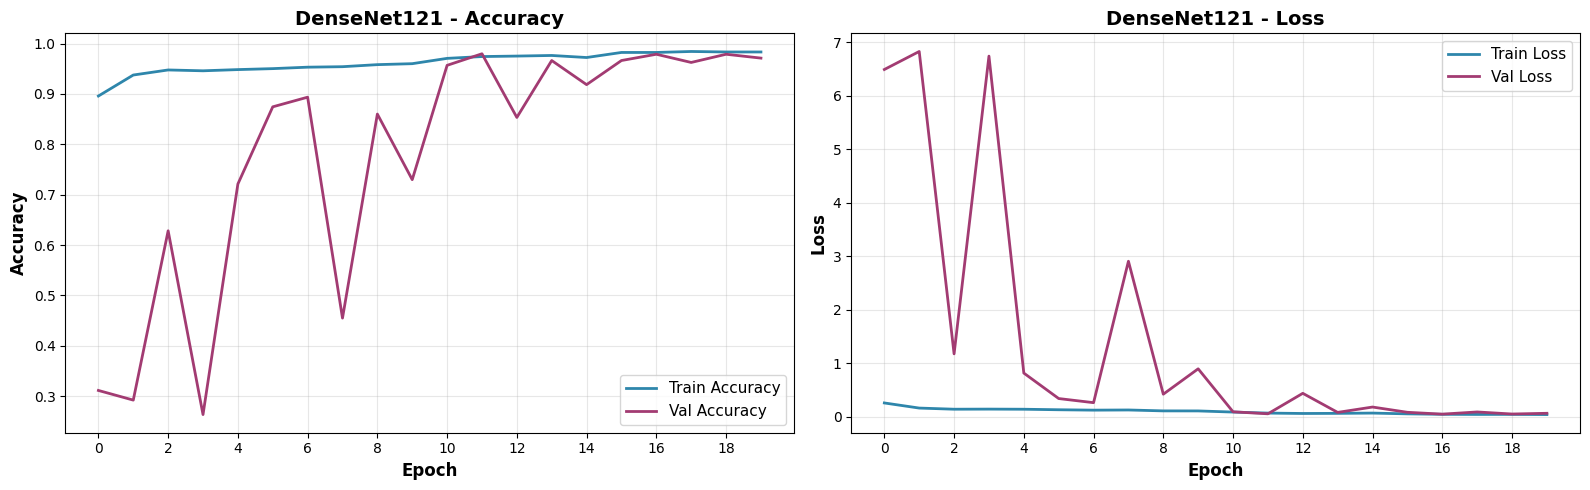

  - Best Epoch: 12
  - Train Accuracy: 0.9744
  - Val Accuracy: 0.9799
  - Train Loss: 0.0689
  - Val Loss: 0.0556


In [19]:
def plot_training_history(history, model_name):
    """Plot training and validation metrics with custom X-axis steps"""
    num_epochs = len(history.history['accuracy'])
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='#2E86AB')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, color='#A23B72')
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(np.arange(0, num_epochs, 2)) 
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2, color='#2E86AB')
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='#A23B72')
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[1].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    axes[1].set_xticks(np.arange(0, num_epochs, 2))    
    plt.tight_layout()
    plt.show()
    
    best_epoch = np.argmax(history.history['val_accuracy'])
    print(f"  - Best Epoch: {best_epoch + 1}")
    print(f"  - Train Accuracy: {history.history['accuracy'][best_epoch]:.4f}")
    print(f"  - Val Accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")
    print(f"  - Train Loss: {history.history['loss'][best_epoch]:.4f}")
    print(f"  - Val Loss: {history.history['val_loss'][best_epoch]:.4f}")

plot_training_history(history_dense, "DenseNet121")

In [20]:
test_loss_dense, test_accuracy_dense = model_dense.evaluate(test_ds_dense, verbose=1)

print(f"  - Test Accuracy: {test_accuracy_dense*100:.2f}%")
print(f"  - Test Loss: {test_loss_dense:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 543ms/step - accuracy: 0.8148 - loss: 0.7081
  - Test Accuracy: 89.42%
  - Test Loss: 0.3931


In [27]:
y_pred_dense = []
y_true_dense = []

for images, labels in test_ds_dense:
    preds = model_dense.predict(images, verbose=0)
    y_pred_dense.extend((preds > 0.7).astype(int).flatten())
    y_true_dense.extend(labels.numpy())

y_pred_dense = np.array(y_pred_dense)
y_true_dense = np.array(y_true_dense)

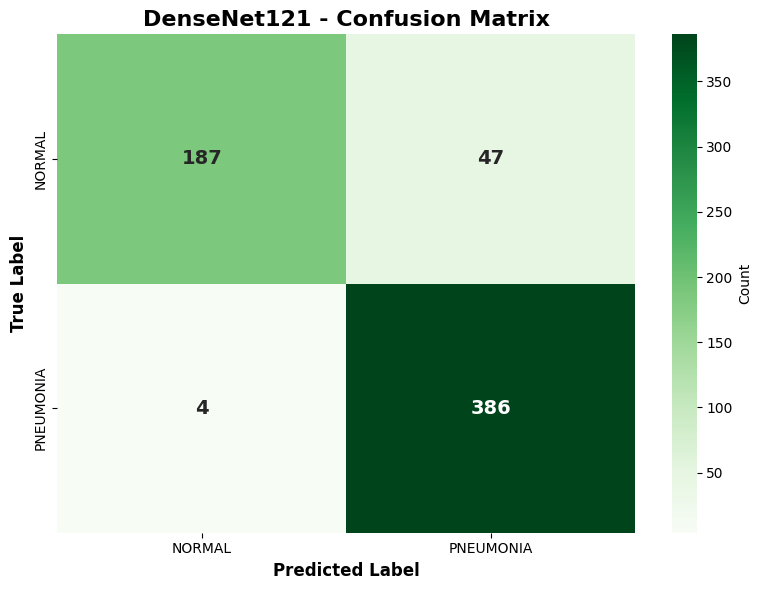


Classification Report (DenseNet121):
              precision    recall  f1-score   support

      NORMAL     0.9791    0.7991    0.8800       234
   PNEUMONIA     0.8915    0.9897    0.9380       390

    accuracy                         0.9183       624
   macro avg     0.9353    0.8944    0.9090       624
weighted avg     0.9243    0.9183    0.9163       624



In [28]:
cm_dense = confusion_matrix(y_true_dense, y_pred_dense)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dense, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'},
            annot_kws={'size': 14, 'weight': 'bold'})

plt.title('DenseNet121 - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nClassification Report (DenseNet121):")
print(classification_report(y_true_dense, y_pred_dense, target_names=class_names, digits=4))